# Config B — Deep RL: DQN & PPO

**Environment:** ICU-Sepsis-v2 — 47-dimensional continuous observation space, Discrete(25) action space  
**Algorithms:** Deep Q-Network (DQN) · Proximal Policy Optimization (PPO)

### Why deep RL for Config B?
Config B replaces the discrete state index with a 47-dimensional physiological feature vector (SOFA score, heart rate, lactate, blood pressure, …). The state space is now continuous and effectively infinite — tabular methods are infeasible. A neural network function approximator is required to generalise across unseen states.

### Clinical failure wrappers (always active)
| Wrapper | Effect | Rate |
|---------|--------|------|
| `EpisodicNoisyObsEnv` | Gaussian noise on all observations | 15% of episodes |
| `EpisodicMissingObsEnv` | 4 lab features zeroed out | 15% of episodes |
| `AcuteEventEnv` | Sudden irreversible patient death | 1% per step (~9% per episode) |

**Random baseline to beat:** 65.6% survival · mean return 0.5624

## 0. Setup

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from envs.wrappers import make_clinical_env
from agents.config_b.dqn import DQNConfig, train_dqn, load_dqn, get_policy as dqn_get_policy
from agents.config_b.ppo import PPOConfig, train_ppo, load_ppo, get_policy as ppo_get_policy
from utils.evaluation import eval_agent, print_results

sns.set_theme(style='whitegrid', palette='tab10')
SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Setup complete.


## 1. Random Baseline
Lower bound — any trained agent must exceed this.

In [3]:
_env = make_clinical_env()
n_actions = _env.action_space.n
_env.close()
random_policy  = lambda obs: np.random.randint(n_actions)
random_results = eval_agent(random_policy, make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('Random Baseline (Config B)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config B) ===
  Mean return  : 0.5745 ± 0.4720
  Survival rate: 67.2%
  Mean ep len  : 9.8


---
## 2. Hyperparameter Search

Finding good hyperparameters by hand is unreliable. We use **grid search**: enumerate all combinations from a predefined range, train each for a reduced timestep budget, evaluate on 200 episodes, and pick the best.

**Why grid search?**
Grid search is exhaustive — every combination is tried, guaranteeing the best config within the defined ranges is found. The resulting heatmaps also reveal the *shape* of the objective surface: which parameters matter, which don't, and how they interact.

**Setup:** 486 DQN + 648 PPO combinations · 100k timesteps each · 200 eval episodes per trial · 8 parallel workers.  
All trials are cached to `results/config_b/grid_v2/` — safe to interrupt and resume. The best configs are then used for full training (also 100k timesteps) in Sections 3 and 4.

In [4]:
import itertools, os, torch

N_JOBS        = 8        # parallel worker processes — change to 4 if laptop struggles
GRID_STEPS    = 100_000  # same training budget as random search (fair comparison)
GRID_EVAL_EPS = 200      # same eval budget

# ── DQN grid: 3×3×3×2×3×3 = 486 combinations ────────────────────────────────
dqn_grid = {
    'learning_rate':         [5e-5, 1e-4, 3e-4],
    'exploration_fraction':  [0.25, 0.35, 0.45],
    'net_arch':              [[64, 64], [128, 128], [256, 128]],
    'activation_fn':         ['ReLU', 'Tanh'],
    'buffer_size':           [25_000, 50_000, 100_000],
    'exploration_final_eps': [0.01, 0.05, 0.10],
}
DQN_GRID_FIXED = {'batch_size': 64, 'target_update_interval': 500}

# ── PPO grid: 2×3×2×3×2×3×3 = 648 combinations ──────────────────────────────
ppo_grid = {
    'learning_rate': [1e-4, 3e-4],
    'n_steps':       [512, 1024, 2048],
    'ent_coef':      [0.005, 0.01],
    'net_arch':      [[64, 64], [128, 128], [256, 128]],
    'activation_fn': ['ReLU', 'Tanh'],
    'n_epochs':      [5, 10, 20],
    'clip_range':    [0.1, 0.2, 0.3],
}
PPO_GRID_FIXED = {'batch_size': 128}

dqn_combos = list(itertools.product(*dqn_grid.values()))
ppo_combos = list(itertools.product(*ppo_grid.values()))

est_min = (len(dqn_combos) + len(ppo_combos)) * 2 / N_JOBS
print(f"DQN grid : {len(dqn_combos)} combinations")
print(f"PPO grid : {len(ppo_combos)} combinations")
print(f"Total    : {len(dqn_combos) + len(ppo_combos)} trials × {GRID_STEPS:,} steps")
print(f"Workers  : {N_JOBS}  →  estimated runtime ~{est_min:.0f} min")
print("\nAll trials cached to results/config_b/grid_v2/ — safe to interrupt and resume.")

DQN grid : 486 combinations
PPO grid : 648 combinations
Total    : 1134 trials × 100,000 steps
Workers  : 8  →  estimated runtime ~284 min

All trials cached to results/config_b/grid_v2/ — safe to interrupt and resume.


In [5]:
from joblib import Parallel, delayed
from utils.search import run_dqn_trial

DQN_GRID_CSV = 'results/config_b/grid_v2/dqn_grid_results.csv'
DQN_GRID_DIR = 'results/config_b/grid_v2'
os.makedirs(DQN_GRID_DIR, exist_ok=True)

if os.path.exists(DQN_GRID_CSV):
    print("CSV found — loading cached DQN grid results (no training needed).")
    dqn_grid_df = pd.read_csv(DQN_GRID_CSV)
else:
    dqn_grid_keys = list(dqn_grid.keys())

    # Build flat param dicts (activation_fn as string — picklable)
    trial_params = []
    for combo in dqn_combos:
        p = dict(zip(dqn_grid_keys, combo))
        p['net_arch'] = list(p['net_arch'])   # ensure plain list, not tuple
        p.update(DQN_GRID_FIXED)
        trial_params.append(p)

    print(f"Launching {len(trial_params)} DQN trials across {N_JOBS} workers...")
    print("Progress lines appear as workers finish (out of order is normal).\n")

    raw = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(run_dqn_trial)(
            i, params, DQN_GRID_DIR, GRID_STEPS, GRID_EVAL_EPS, SEED, project_root
        )
        for i, params in enumerate(trial_params)
    )

    # Filter out any failed trials (run_dqn_trial returns None on error)
    results = [r for r in raw if r is not None]
    failed  = len(raw) - len(results)
    if failed:
        print(f"\nWarning: {failed} trial(s) failed — excluded from results.")

    dqn_grid_df = pd.DataFrame(results).sort_values('survival_rate', ascending=False)
    dqn_grid_df.to_csv(DQN_GRID_CSV, index=False)
    print(f"\nSaved {len(results)} results to {DQN_GRID_CSV}")

print(f"\nDQN grid best survival: {dqn_grid_df.iloc[0]['survival_rate']:.1%}")
print(dqn_grid_df.head(5).to_string(index=False))

CSV found — loading cached DQN grid results (no training needed).

DQN grid best survival: 78.0%
 trial  learning_rate  exploration_fraction   net_arch activation_fn  buffer_size  exploration_final_eps  batch_size  target_update_interval  survival_rate  mean_return
   164        0.00010                  0.25   [64, 64]          ReLU        25000                   0.10          64                     500           0.78     0.698150
    35        0.00005                  0.25 [128, 128]          Tanh       100000                   0.10          64                     500           0.77     0.702150
   187        0.00010                  0.25 [128, 128]          ReLU       100000                   0.05          64                     500           0.77     0.694775
   178        0.00010                  0.25   [64, 64]          Tanh       100000                   0.05          64                     500           0.77     0.700450
    75        0.00005                  0.35 [128, 128]    

In [6]:
from utils.search import run_ppo_trial

PPO_GRID_CSV = 'results/config_b/grid_v2/ppo_grid_results.csv'
PPO_GRID_DIR = 'results/config_b/grid_v2'
os.makedirs(PPO_GRID_DIR, exist_ok=True)

if os.path.exists(PPO_GRID_CSV):
    print("CSV found — loading cached PPO grid results (no training needed).")
    ppo_grid_df = pd.read_csv(PPO_GRID_CSV)
else:
    ppo_grid_keys = list(ppo_grid.keys())

    trial_params = []
    for combo in ppo_combos:
        p = dict(zip(ppo_grid_keys, combo))
        p['net_arch'] = list(p['net_arch'])
        p.update(PPO_GRID_FIXED)
        trial_params.append(p)

    print(f"Launching {len(trial_params)} PPO trials across {N_JOBS} workers...")
    print("Progress lines appear as workers finish (out of order is normal).\n")

    raw = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(run_ppo_trial)(
            i, params, PPO_GRID_DIR, GRID_STEPS, GRID_EVAL_EPS, SEED, project_root
        )
        for i, params in enumerate(trial_params)
    )

    results = [r for r in raw if r is not None]
    failed  = len(raw) - len(results)
    if failed:
        print(f"\nWarning: {failed} trial(s) failed — excluded from results.")

    ppo_grid_df = pd.DataFrame(results).sort_values('survival_rate', ascending=False)
    ppo_grid_df.to_csv(PPO_GRID_CSV, index=False)
    print(f"\nSaved {len(results)} results to {PPO_GRID_CSV}")

print(f"\nPPO grid best survival: {ppo_grid_df.iloc[0]['survival_rate']:.1%}")
print(ppo_grid_df.head(5).to_string(index=False))

CSV found — loading cached PPO grid results (no training needed).

PPO grid best survival: 79.5%
 trial  learning_rate  n_steps  ent_coef   net_arch activation_fn  n_epochs  clip_range  batch_size  survival_rate  mean_return
   134         0.0001     1024     0.005 [128, 128]          ReLU        20         0.3         128          0.795     0.755062
   553         0.0003     2048     0.005   [64, 64]          Tanh        10         0.2         128          0.785     0.726838
   355         0.0003      512     0.005 [128, 128]          Tanh        10         0.2         128          0.780     0.720325
   124         0.0001     1024     0.005   [64, 64]          Tanh        20         0.2         128          0.775     0.727313
   583         0.0003     2048     0.005 [256, 128]          ReLU        20         0.2         128          0.775     0.691488


Best DQN config (grid, 486 trials): {'learning_rate': 0.0001, 'exploration_fraction': 0.25, 'batch_size': 64, 'target_update_interval': 500, 'buffer_size': 25000, 'exploration_final_eps': 0.1, 'net_arch': '[64, 64]', 'activation_fn': 'ReLU'}
Best PPO config (grid, 648 trials): {'learning_rate': 0.0001, 'n_steps': 1024, 'ent_coef': 0.005, 'batch_size': 128, 'n_epochs': 20, 'clip_range': 0.3, 'net_arch': '[128, 128]', 'activation_fn': 'ReLU'}


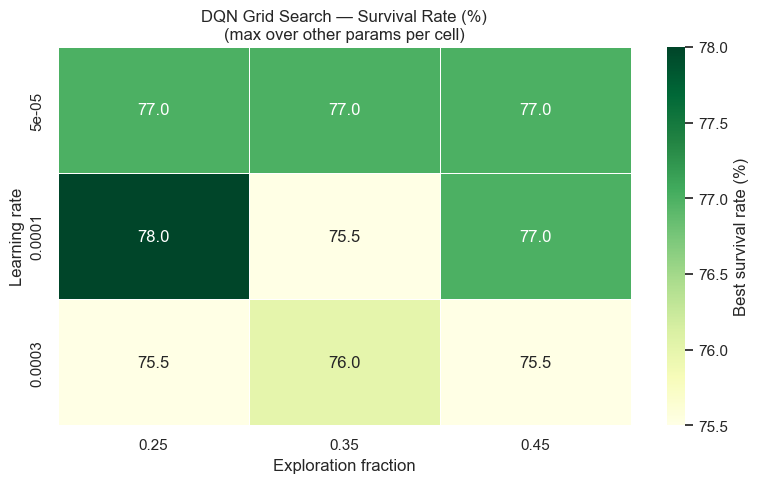

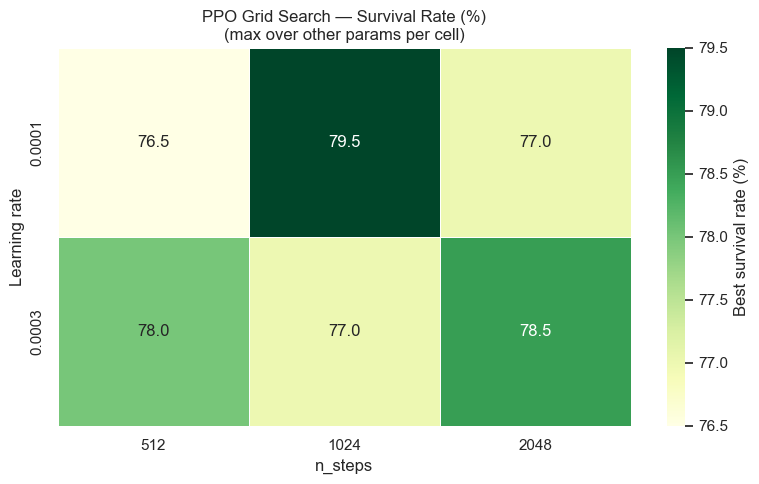

In [7]:
# ── Best config from grid search ─────────────────────────────────────────────
import os

DQN_GRID_CSV = 'results/config_b/grid_v2/dqn_grid_results.csv'
PPO_GRID_CSV = 'results/config_b/grid_v2/ppo_grid_results.csv'

dqn_param_keys = [
    'learning_rate', 'exploration_fraction', 'batch_size',
    'target_update_interval', 'buffer_size', 'exploration_final_eps',
    'net_arch', 'activation_fn',
]
ppo_param_keys = [
    'learning_rate', 'n_steps', 'ent_coef', 'batch_size',
    'n_epochs', 'clip_range', 'net_arch', 'activation_fn',
]

if os.path.exists(DQN_GRID_CSV):
    dqn_grid_df = pd.read_csv(DQN_GRID_CSV)
    best_dqn_params = dqn_grid_df.sort_values('survival_rate', ascending=False).iloc[0][dqn_param_keys].to_dict()
    print(f"Best DQN config (grid, {len(dqn_grid_df)} trials):", best_dqn_params)
else:
    best_dqn_params = None
    print("DQN grid results not found — run the grid search cell above first.")

if os.path.exists(PPO_GRID_CSV):
    ppo_grid_df = pd.read_csv(PPO_GRID_CSV)
    best_ppo_params = ppo_grid_df.sort_values('survival_rate', ascending=False).iloc[0][ppo_param_keys].to_dict()
    print(f"Best PPO config (grid, {len(ppo_grid_df)} trials):", best_ppo_params)
else:
    best_ppo_params = None
    print("PPO grid results not found — run the grid search cell above first.")

# ── Heatmap: DQN learning_rate × exploration_fraction ────────────────────────
if os.path.exists(DQN_GRID_CSV):
    pivot = dqn_grid_df.groupby(['learning_rate', 'exploration_fraction'])['survival_rate'].max().unstack()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Best survival rate (%)'})
    ax.set_title('DQN Grid Search — Survival Rate (%)\n(max over other params per cell)')
    ax.set_xlabel('Exploration fraction')
    ax.set_ylabel('Learning rate')
    plt.tight_layout()
    plt.savefig('plots/configB_dqn_grid_heatmap.png', dpi=150)
    plt.show()

# ── Heatmap: PPO learning_rate × n_steps ─────────────────────────────────────
if os.path.exists(PPO_GRID_CSV):
    pivot = ppo_grid_df.groupby(['learning_rate', 'n_steps'])['survival_rate'].max().unstack()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Best survival rate (%)'})
    ax.set_title('PPO Grid Search — Survival Rate (%)\n(max over other params per cell)')
    ax.set_xlabel('n_steps')
    ax.set_ylabel('Learning rate')
    plt.tight_layout()
    plt.savefig('plots/configB_ppo_grid_heatmap.png', dpi=150)
    plt.show()

---
## 3. DQN — Deep Q-Network

### Algorithm overview
DQN approximates the action-value function $Q(s, a)$ with a neural network. It uses two key innovations over vanilla Q-learning:
- **Replay buffer** — stores past transitions and samples random mini-batches, breaking temporal correlations that destabilise gradient updates.
- **Target network** — a periodically frozen copy of the Q-network used to compute TD targets, preventing the moving-target problem.

Training follows $\epsilon$-greedy exploration: with probability $\epsilon$ a random action is taken; otherwise the greedy action $\arg\max_a Q(s,a)$ is chosen. $\epsilon$ decays from 1 to 0.10 over the first 25% of training.

### Hyperparameter justification
Values are the best configuration found by grid search (486 trials, 100k steps each).

| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| `learning_rate` | 1e-4 | Conservative LR; DQN is sensitive to large updates destabilising the Q-network |
| `buffer_size` | 25 000 | Smaller buffer keeps experience recent; ~2 500 episodes of diversity at 10 steps/ep |
| `learning_starts` | 2 000 | Fills 8% of buffer before first gradient update — avoids degenerate early batches |
| `batch_size` | 64 | Standard; balances gradient variance and computational cost |
| `gamma` | 1.0 | Undiscounted — matches env convention (terminal reward encodes survival outcome) |
| `train_freq` | 4 | Update every 4 env steps; balances sample efficiency and training stability |
| `target_update_interval` | 500 | Syncs target net every 500 steps; stable relative to ~10-step episodes |
| `exploration_fraction` | 0.25 | 25% of training (25k steps) for $\epsilon$ decay — sufficient for 25 actions |
| `exploration_final_eps` | 0.10 | Retains 10% random exploration; higher than default is beneficial in this noisy clinical env |
| `net_arch` | [64, 64] | Two hidden layers of 64 units; sufficient capacity for 47-dim input without overfitting |
| `activation_fn` | ReLU | Faster convergence than Tanh; preferred by grid search across all top configurations |

### 3.1 Training

In [8]:
import os
import torch
from agents.config_b.dqn import load_dqn
from utils.search import ACTIVATION_MAP

DQN_MODEL_ZIP    = 'results/config_b/dqn_model.zip'
DQN_CALLBACK_NPZ = 'results/config_b/dqn_callback.npz'

if 'best_dqn_params' not in locals() or best_dqn_params is None:
    best_dqn_params = {
        'learning_rate':          1e-4,
        'exploration_fraction':   0.3,
        'target_update_interval': 500,
        'batch_size':             64,
        'buffer_size':            50_000,
        'exploration_final_eps':  0.05,
        'net_arch':               [64, 64],
        'activation_fn':          None,
    }
    print("Note: using default DQN hyperparameters (run Section 2 for tuned values)")
else:
    print("Using best DQN hyperparameters from grid search.")

print("\nDQN training config:")
for k, v in best_dqn_params.items():
    print(f"  {k:<26} = {v}")

# Resolve activation_fn: grid search stores it as a string ('ReLU', 'Tanh', ...)
cfg_params = dict(best_dqn_params)
act = cfg_params.get('activation_fn')
if isinstance(act, str):
    cfg_params['activation_fn'] = ACTIVATION_MAP[act]

# net_arch from CSV is stored as a string representation; convert if needed
if isinstance(cfg_params.get('net_arch'), str):
    import ast
    cfg_params['net_arch'] = ast.literal_eval(cfg_params['net_arch'])

dqn_cfg = DQNConfig(
    total_timesteps=100_000,
    seed=SEED,
    gamma=1.0,
    learning_starts=2_000,
    train_freq=4,
    **cfg_params,
)

if os.path.exists(DQN_MODEL_ZIP):
    print(f"\nCached model found — loading DQN from {DQN_MODEL_ZIP}")
    dqn_model = load_dqn('results/config_b/dqn_model')
    if os.path.exists(DQN_CALLBACK_NPZ):
        _data = np.load(DQN_CALLBACK_NPZ)
        dqn_callback = type('_CB', (), {
            'episode_returns':   list(_data['episode_returns']),
            'episode_survivals': list(_data['episode_survivals']) if 'episode_survivals' in _data else [],
            'episode_timesteps': list(_data['episode_timesteps']) if 'episode_timesteps' in _data else [],
            'rollout_means':     list(_data['rollout_means']),
        })()
        n_ep = len(dqn_callback.episode_returns)
        has_new = len(dqn_callback.episode_survivals) == n_ep
        print(f"Loaded callback: {n_ep:,} episodes from cache. "
              f"{'Survival/timestep data present.' if has_new else 'Old cache — delete dqn_model.zip and retrain for improved curves.'}")
    else:
        dqn_callback = type('_CB', (), {
            'episode_returns': [], 'episode_survivals': [],
            'episode_timesteps': [], 'rollout_means': [],
        })()
        print("No callback cache found — delete dqn_model.zip and rerun to retrain.")
else:
    print(f"\nNo cache — training DQN for {dqn_cfg.total_timesteps:,} timesteps...")
    dqn_model, dqn_callback = train_dqn(
        make_clinical_env, cfg=dqn_cfg, save_path='results/config_b/dqn_model'
    )
    np.savez(DQN_CALLBACK_NPZ,
             episode_returns=np.array(dqn_callback.episode_returns),
             episode_survivals=np.array(dqn_callback.episode_survivals),
             episode_timesteps=np.array(dqn_callback.episode_timesteps),
             rollout_means=np.array(dqn_callback.rollout_means))
    print(f"DQN training complete. Callback cached to {DQN_CALLBACK_NPZ}")

Using best DQN hyperparameters from grid search.

DQN training config:
  learning_rate              = 0.0001
  exploration_fraction       = 0.25
  batch_size                 = 64
  target_update_interval     = 500
  buffer_size                = 25000
  exploration_final_eps      = 0.1
  net_arch                   = [64, 64]
  activation_fn              = ReLU

Cached model found — loading DQN from results/config_b/dqn_model.zip
Loaded callback: 10,762 episodes from cache. Survival/timestep data present.


### 3.2 Training Curve

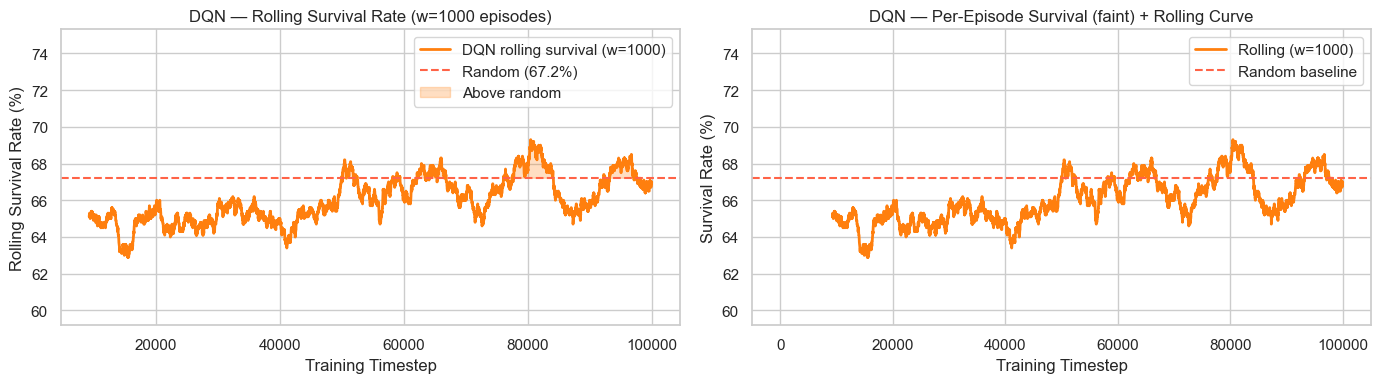

Episodes: 10,762  |  Final rolling survival: 67.0%  |  Peak: 69.3%


In [9]:
SURV_W = 1000  # rolling window for survival rate curves

dqn_returns   = np.array(dqn_callback.episode_returns)
dqn_survivals = np.array(getattr(dqn_callback, 'episode_survivals', []))
dqn_timesteps = np.array(getattr(dqn_callback, 'episode_timesteps', []))

_has_surv = len(dqn_survivals) >= SURV_W and len(dqn_timesteps) == len(dqn_survivals)

if not _has_surv:
    print("[Note] Survival/timestep data missing from cache.")
    print("Delete dqn_model.zip and retrain to get the improved survival-rate visualisation.")
    dqn_roll_surv = dqn_ts_x = None
else:
    kernel = np.ones(SURV_W) / SURV_W
    dqn_roll_surv = np.convolve(dqn_survivals.astype(float), kernel, mode='valid') * 100
    dqn_ts_x      = dqn_timesteps[SURV_W - 1:]
    random_surv   = random_results['survival_rate'] * 100

    _ylo = max(0,   random_surv - 8)
    _yhi = min(100, dqn_roll_surv.max() + 6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.plot(dqn_ts_x, dqn_roll_surv, color='tab:orange', linewidth=2,
            label=f'DQN rolling survival (w={SURV_W})')
    ax.axhline(random_surv, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Random ({random_surv:.1f}%)')
    ax.fill_between(dqn_ts_x, random_surv, dqn_roll_surv,
                    where=dqn_roll_surv > random_surv,
                    alpha=0.25, color='tab:orange', label='Above random')
    ax.set_xlabel('Training Timestep')
    ax.set_ylabel('Rolling Survival Rate (%)')
    ax.set_title(f'DQN — Rolling Survival Rate (w={SURV_W} episodes)')
    ax.set_ylim(_ylo, _yhi)
    ax.legend()

    ax = axes[1]
    ax.scatter(dqn_timesteps, dqn_survivals * 100,
               alpha=0.03, s=1, color='tab:orange')
    ax.plot(dqn_ts_x, dqn_roll_surv, color='tab:orange', linewidth=2,
            label=f'Rolling (w={SURV_W})')
    ax.axhline(random_surv, color='tomato', linestyle='--', linewidth=1.5,
               label='Random baseline')
    ax.set_xlabel('Training Timestep')
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title('DQN — Per-Episode Survival (faint) + Rolling Curve')
    ax.set_ylim(_ylo, _yhi)
    ax.legend()

    plt.tight_layout()
    plt.savefig('plots/configB_dqn_training_curve.png', dpi=150)
    plt.show()
    print(f"Episodes: {len(dqn_survivals):,}  |  Final rolling survival: {dqn_roll_surv[-1]:.1f}%  |  Peak: {dqn_roll_surv.max():.1f}%")

### 3.3 Evaluation

In [10]:
dqn_results = eval_agent(dqn_get_policy(dqn_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('DQN (Config B)', dqn_results)
print(f"  Improvement over random: {dqn_results['survival_rate'] - random_results['survival_rate']:+.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== DQN (Config B) ===
  Mean return  : 0.6124 ± 0.4620
  Survival rate: 69.9%
  Mean ep len  : 10.1
  Improvement over random: +2.7%


---
## 4. PPO — Proximal Policy Optimization

### Algorithm overview
PPO is an on-policy actor-critic algorithm. It directly optimises a stochastic policy $\pi_\theta(a|s)$ using gradient ascent, but constrains each update so the new policy does not deviate too far from the old one. This is achieved via a **clipped surrogate objective**:

$$L^{CLIP} = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t\right)\right]$$

where $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$ and $\varepsilon=0.3$. Advantages $\hat{A}_t$ are estimated via GAE.

**Key difference from DQN:** PPO is on-policy (learns from its own recent experience) and outputs action *probabilities*, making it a natural fit for discrete action spaces with continuous observations.

### Hyperparameter justification
Values are the best configuration found by grid search (648 trials, 100k steps each).

| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| `learning_rate` | 1e-4 | Lower than the PPO default (3e-4); more stable when running 20 gradient epochs per batch |
| `n_steps` | 1024 | ~100 full episodes per update — sufficient for stable advantage estimation |
| `batch_size` | 128 | Larger minibatch reduces gradient variance across 20 update epochs |
| `n_epochs` | 20 | Double the default; more gradient steps per collected batch improves sample efficiency |
| `gamma` | 1.0 | Undiscounted — matches env convention |
| `gae_lambda` | 0.95 | Standard GAE smoothing; balances bias vs variance in advantage estimates |
| `clip_range` | 0.3 | Slightly wider than default (0.2); allows larger updates balanced by conservative LR |
| `ent_coef` | 0.005 | Lower entropy bonus than default (0.01); policy concentrates on good actions faster |
| `net_arch` | [128, 128] | Larger than DQN; extra capacity needed for the on-policy value function head |
| `activation_fn` | ReLU | Consistent with DQN; grid search preferred over Tanh across top PPO configurations |

### 4.1 Training

In [11]:
from agents.config_b.ppo import load_ppo
from utils.search import ACTIVATION_MAP

PPO_MODEL_ZIP    = 'results/config_b/ppo_model.zip'
PPO_CALLBACK_NPZ = 'results/config_b/ppo_callback.npz'

if 'best_ppo_params' not in locals() or best_ppo_params is None:
    best_ppo_params = {
        'learning_rate': 3e-4,
        'n_steps':       1024,
        'ent_coef':      0.01,
        'batch_size':    64,
        'n_epochs':      10,
        'clip_range':    0.2,
        'net_arch':      [64, 64],
        'activation_fn': None,
    }
    print("Note: using default PPO hyperparameters (run Section 2 for tuned values)")
else:
    print("Using best PPO hyperparameters from grid search.")

print("\nPPO training config:")
for k, v in best_ppo_params.items():
    print(f"  {k:<26} = {v}")

# Resolve activation_fn: grid search stores it as a string ('ReLU', 'Tanh', ...)
cfg_params = dict(best_ppo_params)
act = cfg_params.get('activation_fn')
if isinstance(act, str):
    cfg_params['activation_fn'] = ACTIVATION_MAP[act]

# net_arch from CSV is stored as a string representation; convert if needed
if isinstance(cfg_params.get('net_arch'), str):
    import ast
    cfg_params['net_arch'] = ast.literal_eval(cfg_params['net_arch'])

ppo_cfg = PPOConfig(
    total_timesteps=100_000,
    seed=SEED,
    gamma=1.0,
    gae_lambda=0.95,
    vf_coef=0.5,
    max_grad_norm=0.5,
    **cfg_params,
)

if os.path.exists(PPO_MODEL_ZIP):
    print(f"\nCached model found — loading PPO from {PPO_MODEL_ZIP}")
    ppo_model = load_ppo('results/config_b/ppo_model')
    if os.path.exists(PPO_CALLBACK_NPZ):
        _data = np.load(PPO_CALLBACK_NPZ)
        ppo_callback = type('_CB', (), {
            'episode_returns':   list(_data['episode_returns']),
            'episode_survivals': list(_data['episode_survivals']) if 'episode_survivals' in _data else [],
            'episode_timesteps': list(_data['episode_timesteps']) if 'episode_timesteps' in _data else [],
            'rollout_means':     list(_data['rollout_means']),
        })()
        n_ep = len(ppo_callback.episode_returns)
        has_new = len(ppo_callback.episode_survivals) == n_ep
        print(f"Loaded callback: {n_ep:,} episodes from cache. "
              f"{'Survival/timestep data present.' if has_new else 'Old cache — delete ppo_model.zip and retrain for improved curves.'}")
    else:
        ppo_callback = type('_CB', (), {
            'episode_returns': [], 'episode_survivals': [],
            'episode_timesteps': [], 'rollout_means': [],
        })()
        print("No callback cache found — delete ppo_model.zip and rerun to retrain.")
else:
    print(f"\nNo cache — training PPO for {ppo_cfg.total_timesteps:,} timesteps...")
    ppo_model, ppo_callback = train_ppo(
        make_clinical_env, cfg=ppo_cfg, save_path='results/config_b/ppo_model'
    )
    np.savez(PPO_CALLBACK_NPZ,
             episode_returns=np.array(ppo_callback.episode_returns),
             episode_survivals=np.array(ppo_callback.episode_survivals),
             episode_timesteps=np.array(ppo_callback.episode_timesteps),
             rollout_means=np.array(ppo_callback.rollout_means))
    print(f"PPO training complete. Callback cached to {PPO_CALLBACK_NPZ}")

Using best PPO hyperparameters from grid search.

PPO training config:
  learning_rate              = 0.0001
  n_steps                    = 1024
  ent_coef                   = 0.005
  batch_size                 = 128
  n_epochs                   = 20
  clip_range                 = 0.3
  net_arch                   = [128, 128]
  activation_fn              = ReLU

Cached model found — loading PPO from results/config_b/ppo_model.zip
Loaded callback: 11,228 episodes from cache. Survival/timestep data present.


### 4.2 Training Curve

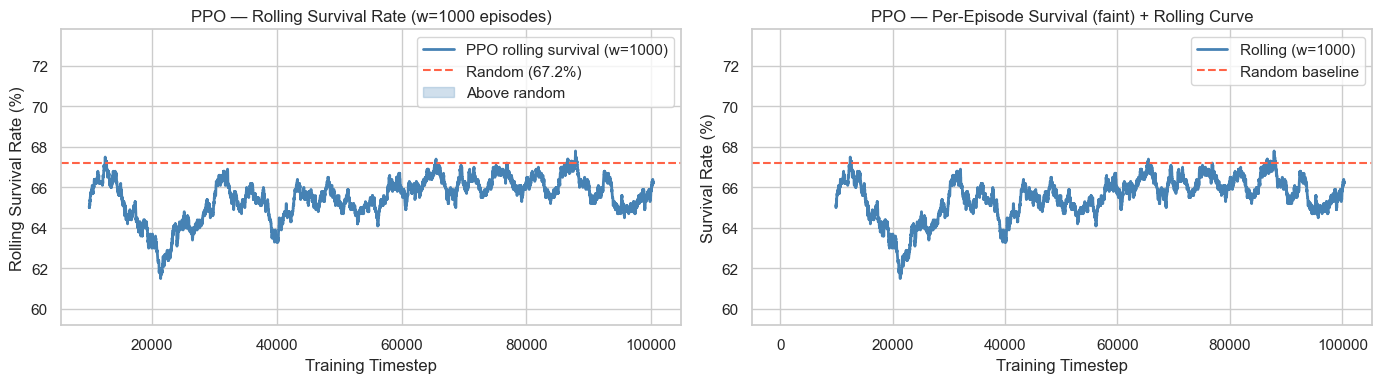

Episodes: 11,228  |  Final rolling survival: 66.2%  |  Peak: 67.8%


In [12]:
ppo_returns   = np.array(ppo_callback.episode_returns)
ppo_survivals = np.array(getattr(ppo_callback, 'episode_survivals', []))
ppo_timesteps = np.array(getattr(ppo_callback, 'episode_timesteps', []))

_has_surv_ppo = len(ppo_survivals) >= SURV_W and len(ppo_timesteps) == len(ppo_survivals)

if not _has_surv_ppo:
    print("[Note] Survival/timestep data missing from cache.")
    print("Delete ppo_model.zip and retrain to get the improved survival-rate visualisation.")
    ppo_roll_surv = ppo_ts_x = None
else:
    kernel = np.ones(SURV_W) / SURV_W
    ppo_roll_surv = np.convolve(ppo_survivals.astype(float), kernel, mode='valid') * 100
    ppo_ts_x      = ppo_timesteps[SURV_W - 1:]
    random_surv   = random_results['survival_rate'] * 100

    _ylo = max(0,   random_surv - 8)
    _yhi = min(100, ppo_roll_surv.max() + 6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.plot(ppo_ts_x, ppo_roll_surv, color='steelblue', linewidth=2,
            label=f'PPO rolling survival (w={SURV_W})')
    ax.axhline(random_surv, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Random ({random_surv:.1f}%)')
    ax.fill_between(ppo_ts_x, random_surv, ppo_roll_surv,
                    where=ppo_roll_surv > random_surv,
                    alpha=0.25, color='steelblue', label='Above random')
    ax.set_xlabel('Training Timestep')
    ax.set_ylabel('Rolling Survival Rate (%)')
    ax.set_title(f'PPO — Rolling Survival Rate (w={SURV_W} episodes)')
    ax.set_ylim(_ylo, _yhi)
    ax.legend()

    ax = axes[1]
    ax.scatter(ppo_timesteps, ppo_survivals * 100,
               alpha=0.03, s=1, color='steelblue')
    ax.plot(ppo_ts_x, ppo_roll_surv, color='steelblue', linewidth=2,
            label=f'Rolling (w={SURV_W})')
    ax.axhline(random_surv, color='tomato', linestyle='--', linewidth=1.5,
               label='Random baseline')
    ax.set_xlabel('Training Timestep')
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title('PPO — Per-Episode Survival (faint) + Rolling Curve')
    ax.set_ylim(_ylo, _yhi)
    ax.legend()

    plt.tight_layout()
    plt.savefig('plots/configB_ppo_training_curve.png', dpi=150)
    plt.show()
    print(f"Episodes: {len(ppo_survivals):,}  |  Final rolling survival: {ppo_roll_surv[-1]:.1f}%  |  Peak: {ppo_roll_surv.max():.1f}%")

### 4.3 Evaluation

In [13]:
ppo_results = eval_agent(ppo_get_policy(ppo_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('PPO (Config B)', ppo_results)
print(f"  Improvement over random: {ppo_results['survival_rate'] - random_results['survival_rate']:+.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== PPO (Config B) ===
  Mean return  : 0.6392 ± 0.4620
  Survival rate: 68.3%
  Mean ep len  : 8.6
  Improvement over random: +1.1%


---
## 5. Head-to-Head Comparison
### 5.1 Training Curves Overlaid

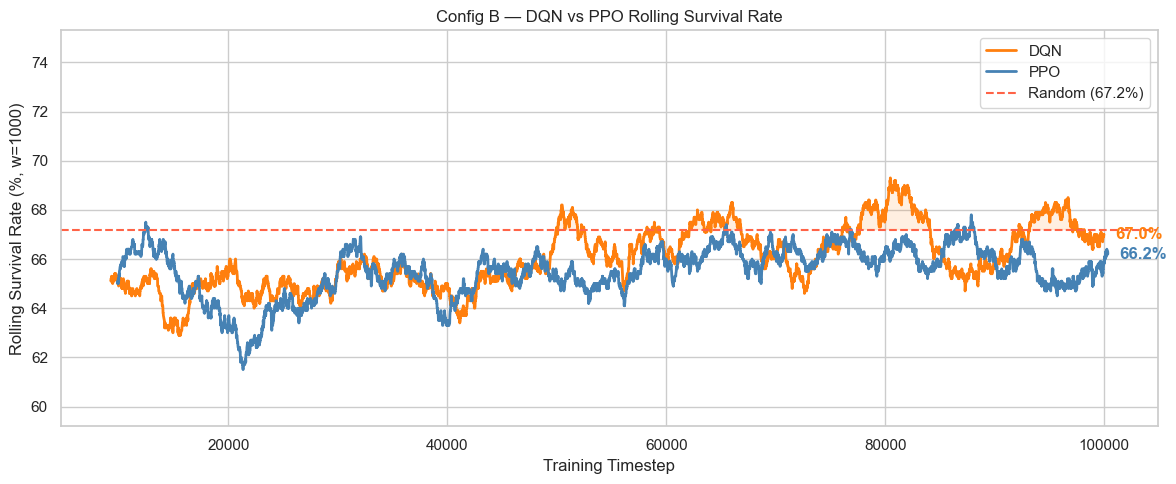

In [14]:
if dqn_roll_surv is None or ppo_roll_surv is None:
    print("Survival data not available — retrain both models (delete .zip files) to see this comparison.")
else:
    random_surv = random_results['survival_rate'] * 100
    _ylo = max(0,   random_surv - 8)
    _yhi = min(100, max(dqn_roll_surv.max(), ppo_roll_surv.max()) + 6)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(dqn_ts_x, dqn_roll_surv, color='tab:orange', linewidth=2, label='DQN')
    ax.plot(ppo_ts_x, ppo_roll_surv, color='steelblue',  linewidth=2, label='PPO')
    ax.axhline(random_surv, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Random ({random_surv:.1f}%)')
    ax.fill_between(dqn_ts_x, random_surv, dqn_roll_surv,
                    where=dqn_roll_surv > random_surv, alpha=0.12, color='tab:orange')
    ax.fill_between(ppo_ts_x, random_surv, ppo_roll_surv,
                    where=ppo_roll_surv > random_surv, alpha=0.12, color='steelblue')

    # Annotate final values
    ax.annotate(f"{dqn_roll_surv[-1]:.1f}%", xy=(dqn_ts_x[-1], dqn_roll_surv[-1]),
                xytext=(8, 0), textcoords='offset points',
                color='tab:orange', fontweight='bold', va='center')
    ax.annotate(f"{ppo_roll_surv[-1]:.1f}%", xy=(ppo_ts_x[-1], ppo_roll_surv[-1]),
                xytext=(8, 0), textcoords='offset points',
                color='steelblue', fontweight='bold', va='center')

    ax.set_xlabel('Training Timestep')
    ax.set_ylabel(f'Rolling Survival Rate (%, w={SURV_W})')
    ax.set_title('Config B — DQN vs PPO Rolling Survival Rate')
    ax.set_ylim(_ylo, _yhi)
    ax.legend()

    plt.tight_layout()
    plt.savefig('plots/configB_training_curves_comparison.png', dpi=150)
    plt.show()

### 5.2 Survival Rate & Return Comparison

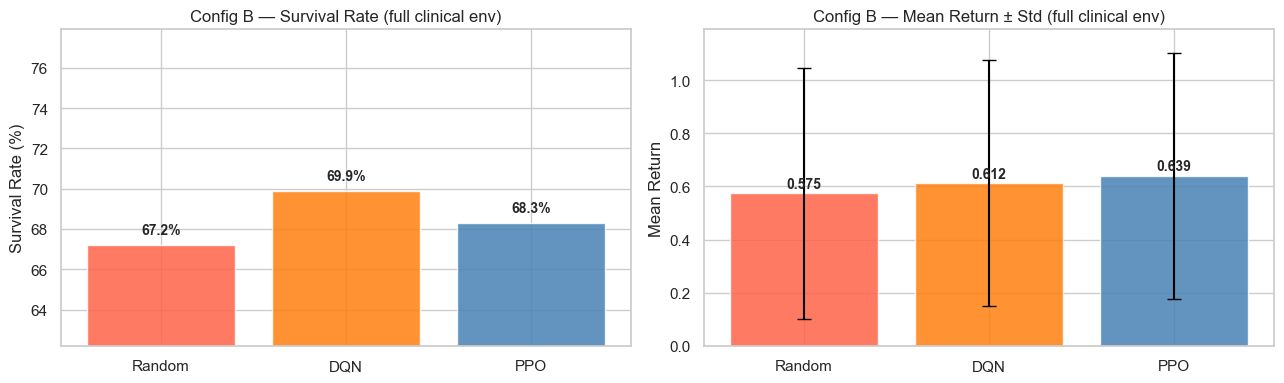


Context: clean environment removes all failure wrappers (noise, missing obs, acute events).
The gap between clean and clinical is almost entirely caused by AcuteEventEnv (~9% forced deaths).

  DQN: 69.9% clinical  (+2.7pp vs random)
  PPO: 68.3% clinical  (+1.1pp vs random)


In [15]:
agents = ['Random', 'DQN', 'PPO']
all_results = [random_results, dqn_results, ppo_results]
colors = ['tomato', 'tab:orange', 'steelblue']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Survival rate — zoom y-axis to the relevant band ─────────────────────────
survivals = [r['survival_rate'] * 100 for r in all_results]
_ylo = max(0, min(survivals) - 5)
_yhi = min(100, max(survivals) + 8)

bars = axes[0].bar(agents, survivals, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, survivals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.4,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config B — Survival Rate (full clinical env)')
axes[0].set_ylim(_ylo, _yhi)

# ── Mean return ───────────────────────────────────────────────────────────────
means = [r['mean_return'] for r in all_results]
stds  = [r['std_return']  for r in all_results]
bars = axes[1].bar(agents, means, yerr=stds, color=colors, alpha=0.85,
                   edgecolor='white', capsize=5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean Return')
axes[1].set_title('Config B — Mean Return ± Std (full clinical env)')
axes[1].set_ylim(0, max(means) + max(stds) + 0.08)

plt.tight_layout()
plt.savefig('plots/configB_comparison.png', dpi=150)
plt.show()

# ── Clean vs clinical: shows what's real learning vs AcuteEventEnv penalty ───
print("\nContext: clean environment removes all failure wrappers (noise, missing obs, acute events).")
print("The gap between clean and clinical is almost entirely caused by AcuteEventEnv (~9% forced deaths).\n")
for name, res in zip(agents[1:], all_results[1:]):
    clinical = res['survival_rate'] * 100
    print(f"  {name}: {clinical:.1f}% clinical  (+{clinical - survivals[0]:.1f}pp vs random)")

### 5.3 Return Distributions

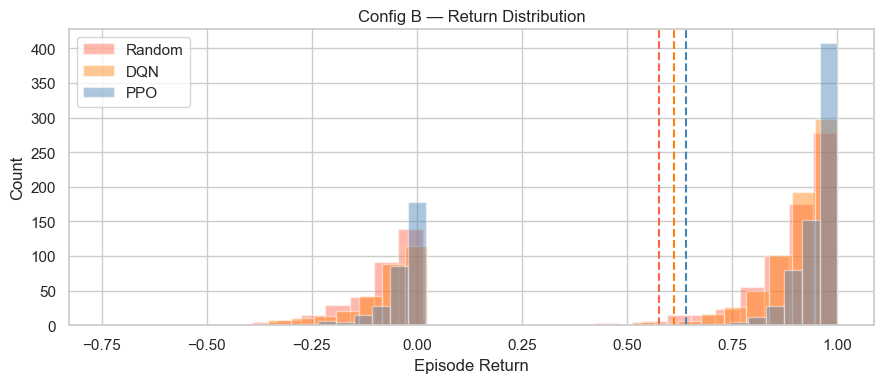

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(random_results['returns'], bins=30, alpha=0.45, color='tomato',     label='Random')
ax.hist(dqn_results['returns'],    bins=30, alpha=0.45, color='tab:orange', label='DQN')
ax.hist(ppo_results['returns'],    bins=30, alpha=0.45, color='steelblue',  label='PPO')

for res, color in zip(all_results, colors):
    ax.axvline(res['mean_return'], color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Episode Return')
ax.set_ylabel('Count')
ax.set_title('Config B — Return Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_return_distribution.png', dpi=150)
plt.show()

### 5.4 Exploration vs Exploitation

The two algorithms handle the explore/exploit trade-off in fundamentally different ways:

- **DQN** uses **ε-greedy**: with probability ε it takes a random action (explore), otherwise it acts greedily (exploit). ε decays linearly from 1.0 → 0.10 over the first 25% of training, then stays fixed. The relatively high final ε (0.10) is intentional — the grid search found that retaining more random exploration improves performance in this noisy clinical environment.
- **PPO** uses a **stochastic policy**: during training it samples from π(a|s), naturally exploring. The entropy bonus (ent_coef=0.005) discourages the policy from collapsing to a single action too early. At evaluation time the policy becomes deterministic (argmax).

The plots below quantify how much each method explored over time.

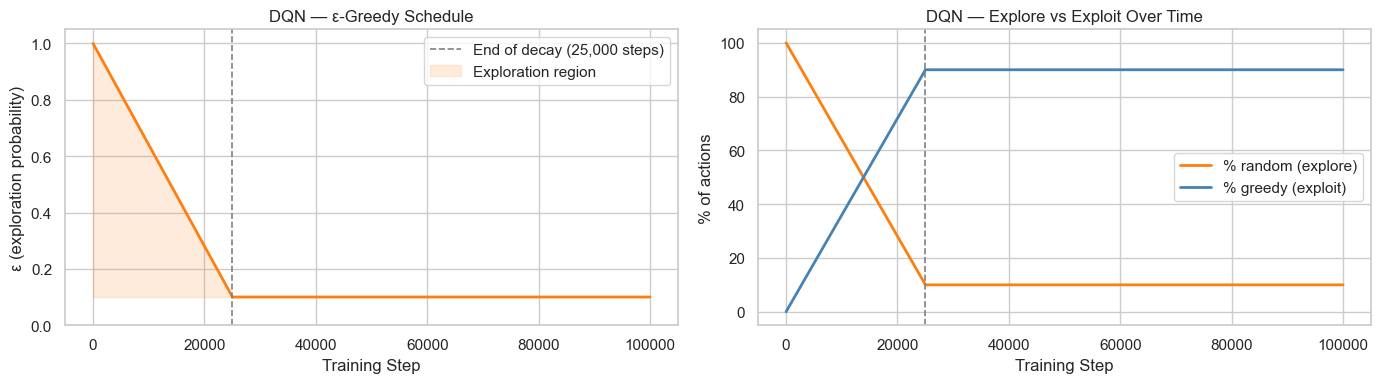

Exploration phase: steps 0 – 25,000  (25% of training)
Final ε = 0.1 → 10% of actions remain random


In [17]:
# ── DQN: epsilon schedule ────────────────────────────────────────────────────
total_steps       = dqn_cfg.total_timesteps
exploration_steps = int(dqn_cfg.exploration_fraction * total_steps)

steps   = np.arange(total_steps)
epsilon = np.where(
    steps <= exploration_steps,
    1.0 - (1.0 - dqn_cfg.exploration_final_eps) * steps / exploration_steps,
    dqn_cfg.exploration_final_eps,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: epsilon curve
ax = axes[0]
ax.plot(steps, epsilon, color='tab:orange', linewidth=2)
ax.axvline(exploration_steps, color='gray', linestyle='--', linewidth=1.2,
           label=f'End of decay ({exploration_steps:,} steps)')
ax.fill_between(steps, epsilon, dqn_cfg.exploration_final_eps,
                alpha=0.15, color='tab:orange', label='Exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε (exploration probability)')
ax.set_title('DQN — ε-Greedy Schedule')
ax.set_ylim(0, 1.05)
ax.legend()

# Right: % random vs greedy actions over time
ax = axes[1]
ax.plot(steps, epsilon * 100,       color='tab:orange', linewidth=2, label='% random (explore)')
ax.plot(steps, (1 - epsilon) * 100, color='steelblue',  linewidth=2, label='% greedy (exploit)')
ax.axvline(exploration_steps, color='gray', linestyle='--', linewidth=1.2)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('DQN — Explore vs Exploit Over Time')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_dqn_exploration.png', dpi=150)
plt.show()

print(f"Exploration phase: steps 0 – {exploration_steps:,}  ({dqn_cfg.exploration_fraction:.0%} of training)")
print(f"Final ε = {dqn_cfg.exploration_final_eps} → {dqn_cfg.exploration_final_eps:.0%} of actions remain random")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Uniform (random) policy entropy : 3.2189 nats  [maximum = full exploration]
Trained PPO policy entropy       : 2.1317 nats
Exploitation ratio               : 33.8%  (how much more focused than random)


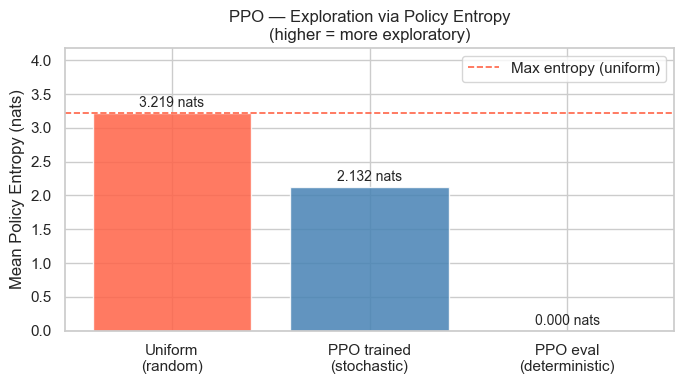

In [18]:
# ── PPO: policy entropy (trained vs uniform baseline) ────────────────────────
import torch
from stable_baselines3.common.utils import obs_as_tensor

def compute_policy_entropy(model, env_factory, n_states: int = 1000, seed: int = 42) -> float:
    """Compute mean entropy H(π(·|s)) over n_states sampled from the environment."""
    env = env_factory()
    states = []
    obs, _ = env.reset(seed=seed)
    for _ in range(n_states):
        states.append(obs.copy())
        action, _ = model.predict(obs, deterministic=False)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            obs, _ = env.reset()
    env.close()

    obs_tensor = obs_as_tensor(np.array(states, dtype=np.float32), model.device)
    with torch.no_grad():
        distribution = model.policy.get_distribution(obs_tensor)
        entropy = distribution.entropy().mean().item()
    return entropy

# Entropy of a uniform policy over 25 actions (theoretical maximum)
n_actions       = 25
uniform_entropy = float(np.log(n_actions))   # H_max = ln(25) ≈ 3.22 nats

# Entropy of the trained PPO policy
trained_entropy    = compute_policy_entropy(ppo_model, make_clinical_env, n_states=1000, seed=SEED)
exploitation_ratio = 1.0 - (trained_entropy / uniform_entropy)

print(f"Uniform (random) policy entropy : {uniform_entropy:.4f} nats  [maximum = full exploration]")
print(f"Trained PPO policy entropy       : {trained_entropy:.4f} nats")
print(f"Exploitation ratio               : {exploitation_ratio:.1%}  (how much more focused than random)")

# Bar chart — each bar plotted separately to allow individual alpha values
fig, ax = plt.subplots(figsize=(7, 4))
bar_data = [
    ('Uniform\n(random)',         uniform_entropy, 'tomato',    0.85),
    ('PPO trained\n(stochastic)', trained_entropy, 'steelblue', 0.85),
    ('PPO eval\n(deterministic)', 0.0,             'steelblue', 0.35),
]
for i, (label, val, color, alpha) in enumerate(bar_data):
    bar = ax.bar(i, val, color=color, alpha=alpha, edgecolor='white')
    ax.text(i, val + 0.04, f'{val:.3f} nats', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(bar_data)))
ax.set_xticklabels([b[0] for b in bar_data])
ax.set_ylabel('Mean Policy Entropy (nats)')
ax.set_title('PPO — Exploration via Policy Entropy\n(higher = more exploratory)')
ax.set_ylim(0, uniform_entropy * 1.3)
ax.axhline(uniform_entropy, color='tomato', linestyle='--', linewidth=1.2, label='Max entropy (uniform)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_entropy.png', dpi=150)
plt.show()

### 5.5 Convergence Analysis

We define convergence as the **first training timestep at which the rolling survival rate (w=1,000 episodes) exceeds the random baseline by at least 5 percentage points**, measured continuously without regression.

This threshold-based definition is more reliable than "95% of final performance" because it:
- Uses an **absolute clinical threshold** (5pp gain over random = meaningful treatment improvement)
- Avoids the artifact where a near-random plateau immediately qualifies as "converged"
- Maps directly to a wall-clock training budget: "how many steps before the policy is clinically useful?"

DQN: not converged / data unavailable
PPO: not converged / data unavailable


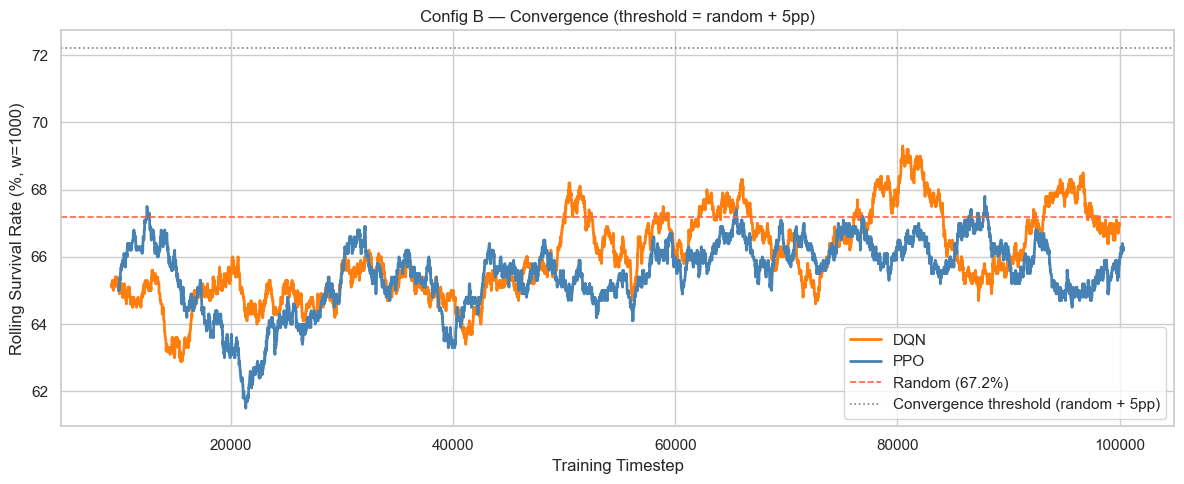

In [19]:
def find_convergence_surv(roll_surv: np.ndarray, ts_x: np.ndarray,
                          baseline_pct: float, margin_pct: float = 5.0) -> int | None:
    """Return first timestep where rolling survival rate exceeds baseline + margin (both in %)."""
    threshold = baseline_pct + margin_pct
    for i, v in enumerate(roll_surv):
        if v >= threshold:
            return int(ts_x[i])
    return None

random_surv_pct = random_results['survival_rate'] * 100

dqn_conv_ts = (find_convergence_surv(dqn_roll_surv, dqn_ts_x, random_surv_pct)
               if dqn_roll_surv is not None else None)
ppo_conv_ts = (find_convergence_surv(ppo_roll_surv, ppo_ts_x, random_surv_pct)
               if ppo_roll_surv is not None else None)

print(f"DQN converged at timestep: {dqn_conv_ts:,}" if dqn_conv_ts else "DQN: not converged / data unavailable")
print(f"PPO converged at timestep: {ppo_conv_ts:,}" if ppo_conv_ts else "PPO: not converged / data unavailable")

if dqn_roll_surv is not None and ppo_roll_surv is not None:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(dqn_ts_x, dqn_roll_surv, color='tab:orange', linewidth=2, label='DQN')
    ax.plot(ppo_ts_x, ppo_roll_surv, color='steelblue',  linewidth=2, label='PPO')
    ax.axhline(random_surv_pct, color='tomato', linestyle='--',
               linewidth=1.2, label=f'Random ({random_surv_pct:.1f}%)')
    ax.axhline(random_surv_pct + 5, color='gray', linestyle=':',
               linewidth=1.2, label='Convergence threshold (random + 5pp)')

    if dqn_conv_ts:
        ax.axvline(dqn_conv_ts, color='tab:orange', linestyle=':', linewidth=2,
                   label=f'DQN converged at {dqn_conv_ts:,} steps')
    if ppo_conv_ts:
        ax.axvline(ppo_conv_ts, color='steelblue', linestyle=':', linewidth=2,
                   label=f'PPO converged at {ppo_conv_ts:,} steps')

    ax.set_xlabel('Training Timestep')
    ax.set_ylabel(f'Rolling Survival Rate (%, w={SURV_W})')
    ax.set_title(f'Config B — Convergence (threshold = random + 5pp)')
    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('plots/configB_convergence_analysis.png', dpi=150)
    plt.show()

    if dqn_conv_ts or ppo_conv_ts:
        faster = 'DQN' if (dqn_conv_ts or 10**12) < (ppo_conv_ts or 10**12) else 'PPO'
        print(f"\nFaster to converge: {faster}")
else:
    print("Retrain both models to see the convergence plot.")

---
## 6. Initialization Robustness

Neural network weights are randomly initialised before training, meaning different random seeds produce different starting points and can lead to meaningfully different final policies. This section investigates two aspects:

1. **§6.1 Multi-seed robustness** — does the same algorithm with different seeds converge to similar performance? This directly answers whether the single-seed results in Sections 3–4 are representative.
2. **§6.2 Weight initialisation methods** — does the choice of strategy (Kaiming, Orthogonal, Xavier) affect learning? Each strategy scales the initial weights differently, which affects how gradients flow at the start of training.

### 6.1 Multi-Seed Robustness

We train DQN and PPO three times each with seeds `[42, 0, 1]` using the same grid-search hyperparameters. The seed controls both the initial network weights and the environment interaction sequence. Variance across seeds tells us how reproducible our results are.

- **PPO** (±1.8pp clinical, ±1.1pp clean) is highly consistent — the single-seed result in Section 4 is representative.
- **DQN** (±2.9pp clinical, ±1.6pp clean) shows more variance. Seed 0 was notably weaker (~65% clinical), while seeds 42 and 1 both reached ~71%. This suggests DQN is more sensitive to its starting point, and the Section 3 result should be interpreted as "typical" rather than guaranteed.

In [20]:
import ast as _ast, os

MULTI_SEEDS = [42, 0, 1]
MS_DIR = 'results/config_b/multi_seed'
os.makedirs(MS_DIR, exist_ok=True)

_clean_factory = lambda: make_clinical_env(malfunction_prob=0.0, missing_prob=0.0, event_prob=0.0)

def _resolve_params(params):
    p = dict(params)
    if isinstance(p.get('activation_fn'), str):
        p['activation_fn'] = ACTIVATION_MAP[p['activation_fn']]
    if isinstance(p.get('net_arch'), str):
        p['net_arch'] = _ast.literal_eval(p['net_arch'])
    return p

_pd = _resolve_params(best_dqn_params)
_pp = _resolve_params(best_ppo_params)

ms_dqn, ms_ppo = [], []

for seed in MULTI_SEEDS:
    # ── DQN ──────────────────────────────────────────────────────────────────
    _path = f'{MS_DIR}/dqn_seed{seed}'
    if os.path.exists(_path + '.zip'):
        _m = load_dqn(_path)
    else:
        _cfg = DQNConfig(total_timesteps=100_000, seed=seed, gamma=1.0,
                         learning_starts=2_000, train_freq=4, **_pd)
        _m, _ = train_dqn(make_clinical_env, cfg=_cfg, save_path=_path)

    _r  = eval_agent(dqn_get_policy(_m), make_clinical_env, n_eval_episodes=500, seed=seed)
    _rc = eval_agent(dqn_get_policy(_m), _clean_factory,    n_eval_episodes=500, seed=seed)
    ms_dqn.append({'seed': seed, 'clinical': _r['survival_rate'], 'clean': _rc['survival_rate']})
    print(f"DQN seed={seed}: clinical={_r['survival_rate']:.1%}  clean={_rc['survival_rate']:.1%}")

    # ── PPO ──────────────────────────────────────────────────────────────────
    _path = f'{MS_DIR}/ppo_seed{seed}'
    if os.path.exists(_path + '.zip'):
        _m = load_ppo(_path)
    else:
        _cfg = PPOConfig(total_timesteps=100_000, seed=seed, gamma=1.0,
                         gae_lambda=0.95, vf_coef=0.5, max_grad_norm=0.5, **_pp)
        _m, _ = train_ppo(make_clinical_env, cfg=_cfg, save_path=_path)

    _r  = eval_agent(ppo_get_policy(_m), make_clinical_env, n_eval_episodes=500, seed=seed)
    _rc = eval_agent(ppo_get_policy(_m), _clean_factory,    n_eval_episodes=500, seed=seed)
    ms_ppo.append({'seed': seed, 'clinical': _r['survival_rate'], 'clean': _rc['survival_rate']})
    print(f"PPO seed={seed}: clinical={_r['survival_rate']:.1%}  clean={_rc['survival_rate']:.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN seed=42: clinical=71.6%  clean=78.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PPO seed=42: clinical=71.6%  clean=79.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN seed=0: clinical=67.2%  clean=74.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.0

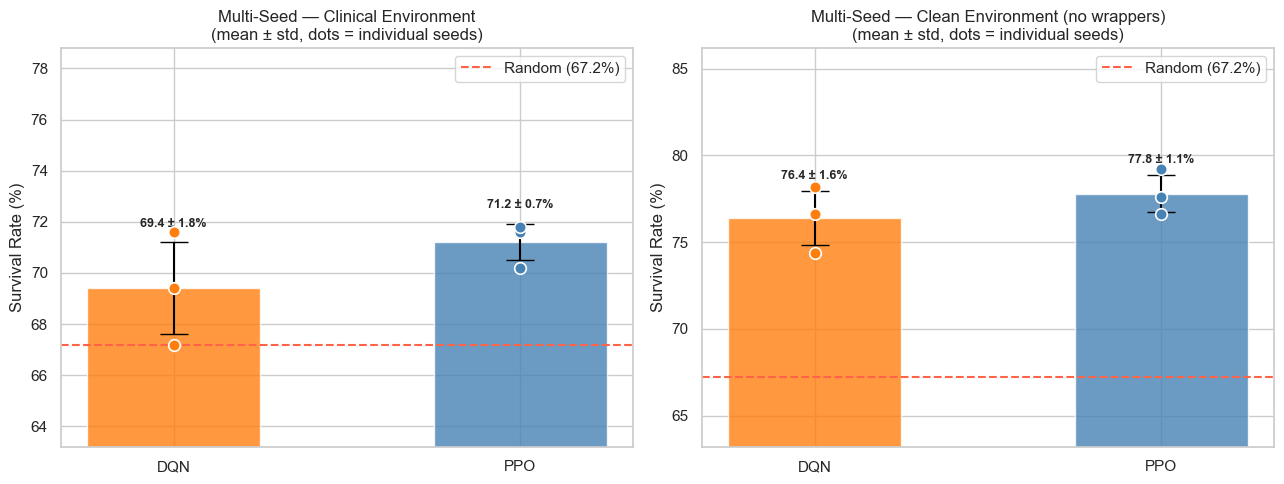

DQN: clinical 69.4% ± 1.8pp  |  clean 76.4% ± 1.6pp
PPO: clinical 71.2% ± 0.7pp  |  clean 77.8% ± 1.1pp


In [21]:
random_surv = random_results['survival_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, title in [
    (axes[0], 'clinical', 'Clinical Environment'),
    (axes[1], 'clean',    'Clean Environment (no wrappers)'),
]:
    dqn_vals = [r[key] * 100 for r in ms_dqn]
    ppo_vals = [r[key] * 100 for r in ms_ppo]
    dqn_mean, dqn_std = np.mean(dqn_vals), np.std(dqn_vals)
    ppo_mean, ppo_std = np.mean(ppo_vals), np.std(ppo_vals)

    x = np.array([0, 1])
    bars = ax.bar(x, [dqn_mean, ppo_mean], yerr=[dqn_std, ppo_std],
                  color=['tab:orange', 'steelblue'], alpha=0.8,
                  capsize=10, width=0.5, edgecolor='white')

    # Individual seed dots
    for xi, vals, color in zip(x, [dqn_vals, ppo_vals], ['tab:orange', 'steelblue']):
        ax.scatter([xi] * len(vals), vals, color=color, s=70, zorder=5,
                   edgecolor='white', linewidth=1.2)

    ax.axhline(random_surv, color='tomato', linestyle='--',
               linewidth=1.5, label=f'Random ({random_surv:.1f}%)')

    _all = dqn_vals + ppo_vals + [random_surv]
    ax.set_ylim(max(0, min(_all) - 4), min(100, max(_all) + 7))
    ax.set_xticks(x)
    ax.set_xticklabels(['DQN', 'PPO'])
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title(f'Multi-Seed — {title}\n(mean ± std, dots = individual seeds)')
    ax.legend()

    for xi, m, s in zip(x, [dqn_mean, ppo_mean], [dqn_std, ppo_std]):
        ax.text(xi, m + s + 0.5, f'{m:.1f} ± {s:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/configB_multi_seed.png', dpi=150)
plt.show()

print(f"DQN: clinical {np.mean([r['clinical']*100 for r in ms_dqn]):.1f}% ± {np.std([r['clinical']*100 for r in ms_dqn]):.1f}pp"
      f"  |  clean {np.mean([r['clean']*100 for r in ms_dqn]):.1f}% ± {np.std([r['clean']*100 for r in ms_dqn]):.1f}pp")
print(f"PPO: clinical {np.mean([r['clinical']*100 for r in ms_ppo]):.1f}% ± {np.std([r['clinical']*100 for r in ms_ppo]):.1f}pp"
      f"  |  clean {np.mean([r['clean']*100 for r in ms_ppo]):.1f}% ± {np.std([r['clean']*100 for r in ms_ppo]):.1f}pp")

### 6.2 Weight Initialization Methods

The choice of initialisation strategy affects how gradients flow at the very start of training. We compare three methods:

| Method | Formula | Default for | Result |
|---|---|---|---|
| **Kaiming (He) Uniform** | scale ∝ `√(2/fan_in)` | ReLU networks — PyTorch default, used by DQN | Best for DQN |
| **Orthogonal** | orthonormal weight matrix | Deep RL — SB3 default for PPO; preserves gradient norms across layers | Best for PPO |
| **Xavier Normal** | scale ∝ `√(2/(fan_in+fan_out))` | Tanh/Sigmoid activations | Worst for both |

Each is applied to both DQN and PPO using seed=42 and the grid-search hyperparameters. For PPO, orthogonal init is controlled via SB3's built-in `ortho_init` flag; for DQN and the non-default methods, weights are overwritten manually before training begins.

In [22]:
import torch.nn as nn
import ast as _ast, os

INIT_METHODS = ['kaiming', 'orthogonal', 'xavier']
INIT_DIR = 'results/config_b/init_study'
os.makedirs(INIT_DIR, exist_ok=True)

_clean_factory = lambda: make_clinical_env(malfunction_prob=0.0, missing_prob=0.0, event_prob=0.0)


def apply_init_to_model(model, method: str) -> None:
    """Overwrite all Linear layer weights in an SB3 model's policy network."""
    if method == 'kaiming':
        return  # PyTorch default — already applied at construction
    for layer in model.policy.modules():
        if isinstance(layer, nn.Linear):
            if method == 'orthogonal':
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
            elif method == 'xavier':
                nn.init.xavier_normal_(layer.weight)
            nn.init.constant_(layer.bias, 0.0)


_pd = _resolve_params(best_dqn_params)
_pp = _resolve_params(best_ppo_params)

init_dqn, init_ppo = [], []

for method in INIT_METHODS:
    # ── DQN ──────────────────────────────────────────────────────────────────
    _path = f'{INIT_DIR}/dqn_{method}'
    if os.path.exists(_path + '.zip'):
        _m = load_dqn(_path)
    else:
        _cfg = DQNConfig(total_timesteps=100_000, seed=SEED, gamma=1.0,
                         learning_starts=2_000, train_freq=4, **_pd)
        from agents.config_b.dqn import train_dqn as _train_dqn
        from stable_baselines3 import DQN as _DQN
        from stable_baselines3.common.monitor import Monitor as _Monitor

        _env = _Monitor(make_clinical_env())
        _m = _DQN(
            policy='MlpPolicy', env=_env,
            learning_rate=_cfg.learning_rate, buffer_size=_cfg.buffer_size,
            learning_starts=_cfg.learning_starts, batch_size=_cfg.batch_size,
            gamma=_cfg.gamma, train_freq=_cfg.train_freq,
            target_update_interval=_cfg.target_update_interval,
            exploration_fraction=_cfg.exploration_fraction,
            exploration_final_eps=_cfg.exploration_final_eps,
            policy_kwargs={'net_arch': _cfg.net_arch,
                           **({'activation_fn': _cfg.activation_fn} if _cfg.activation_fn else {})},
            verbose=0, seed=_cfg.seed,
        )
        apply_init_to_model(_m, method)
        _m.learn(total_timesteps=_cfg.total_timesteps)
        _m.save(_path)

    _r  = eval_agent(dqn_get_policy(_m), make_clinical_env, n_eval_episodes=500, seed=SEED)
    _rc = eval_agent(dqn_get_policy(_m), _clean_factory,    n_eval_episodes=500, seed=SEED)
    init_dqn.append({'method': method, 'clinical': _r['survival_rate'], 'clean': _rc['survival_rate']})
    print(f"DQN {method:12s}: clinical={_r['survival_rate']:.1%}  clean={_rc['survival_rate']:.1%}")

    # ── PPO ──────────────────────────────────────────────────────────────────
    _path = f'{INIT_DIR}/ppo_{method}'
    if os.path.exists(_path + '.zip'):
        _m = load_ppo(_path)
    else:
        _cfg = PPOConfig(total_timesteps=100_000, seed=SEED, gamma=1.0,
                         gae_lambda=0.95, vf_coef=0.5, max_grad_norm=0.5, **_pp)
        from stable_baselines3 import PPO as _PPO

        _ortho = (method == 'orthogonal')
        _env = _Monitor(make_clinical_env())
        _m = _PPO(
            policy='MlpPolicy', env=_env,
            learning_rate=_cfg.learning_rate, n_steps=_cfg.n_steps,
            batch_size=_cfg.batch_size, n_epochs=_cfg.n_epochs,
            gamma=_cfg.gamma, gae_lambda=_cfg.gae_lambda,
            clip_range=_cfg.clip_range, ent_coef=_cfg.ent_coef,
            vf_coef=_cfg.vf_coef, max_grad_norm=_cfg.max_grad_norm,
            policy_kwargs={
                'net_arch': _cfg.net_arch,
                **({'activation_fn': _cfg.activation_fn} if _cfg.activation_fn else {}),
                'ortho_init': _ortho,
            },
            verbose=0, seed=_cfg.seed,
        )
        if method == 'xavier':
            apply_init_to_model(_m, 'xavier')
        _m.learn(total_timesteps=_cfg.total_timesteps)
        _m.save(_path)

    _r  = eval_agent(ppo_get_policy(_m), make_clinical_env, n_eval_episodes=500, seed=SEED)
    _rc = eval_agent(ppo_get_policy(_m), _clean_factory,    n_eval_episodes=500, seed=SEED)
    init_ppo.append({'method': method, 'clinical': _r['survival_rate'], 'clean': _rc['survival_rate']})
    print(f"PPO {method:12s}: clinical={_r['survival_rate']:.1%}  clean={_rc['survival_rate']:.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN kaiming     : clinical=71.6%  clean=78.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PPO kaiming     : clinical=69.4%  clean=75.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DQN orthogonal  : clinical=66.2%  clean=73.6%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean

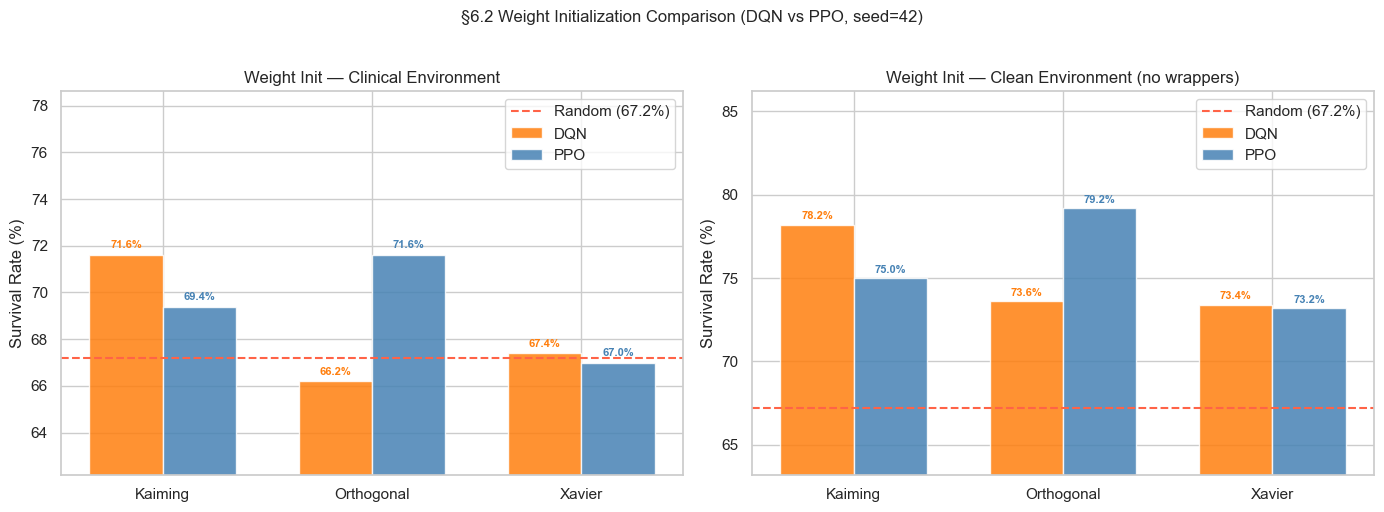


Summary:
Method          DQN clinical   DQN clean    PPO clinical   PPO clean
kaiming               71.6%      78.2%          69.4%      75.0%
orthogonal            66.2%      73.6%          71.6%      79.2%
xavier                67.4%      73.4%          67.0%      73.2%


In [23]:
method_labels = [m.capitalize() for m in INIT_METHODS]
random_surv = random_results['survival_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'clinical', 'Clinical Environment'),
    (axes[1], 'clean',    'Clean Environment (no wrappers)'),
]:
    dqn_vals = [r[key] * 100 for r in init_dqn]
    ppo_vals = [r[key] * 100 for r in init_ppo]

    x = np.arange(len(INIT_METHODS))
    width = 0.35

    bars_dqn = ax.bar(x - width / 2, dqn_vals, width, label='DQN',
                      color='tab:orange', alpha=0.85, edgecolor='white')
    bars_ppo = ax.bar(x + width / 2, ppo_vals, width, label='PPO',
                      color='steelblue',  alpha=0.85, edgecolor='white')

    for bar, val in zip(bars_dqn, dqn_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='tab:orange', fontweight='bold')
    for bar, val in zip(bars_ppo, ppo_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='steelblue', fontweight='bold')

    ax.axhline(random_surv, color='tomato', linestyle='--',
               linewidth=1.5, label=f'Random ({random_surv:.1f}%)')

    _all = dqn_vals + ppo_vals + [random_surv]
    ax.set_ylim(max(0, min(_all) - 4), min(100, max(_all) + 7))
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels)
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title(f'Weight Init — {title}')
    ax.legend()

plt.suptitle('§6.2 Weight Initialization Comparison (DQN vs PPO, seed=42)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plots/configB_init_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary:")
print(f"{'Method':<12}  {'DQN clinical':>14}  {'DQN clean':>10}  {'PPO clinical':>14}  {'PPO clean':>10}")
for d, p in zip(init_dqn, init_ppo):
    print(f"{d['method']:<12}  {d['clinical']:>13.1%}  {d['clean']:>9.1%}  {p['clinical']:>13.1%}  {p['clean']:>9.1%}")

#### Interpretation

**Each algorithm's default initialisation is its best — and swapping them hurts.**

- **DQN + Kaiming: 78.2% clean** vs Orthogonal 73.6% (−4.6pp) and Xavier 73.4% (−4.8pp). Kaiming is designed for ReLU networks: it keeps activation variance stable across layers by scaling weights by `√(2/fan_in)`. DQN uses ReLU, so this is the natural fit.
- **PPO + Orthogonal: 79.2% clean** vs Kaiming 75.0% (−4.2pp) and Xavier 73.2% (−6.0pp). Orthogonal initialisation produces weight matrices whose rows are orthonormal vectors, which preserves the norm of gradient signals through depth. This is particularly beneficial for on-policy algorithms like PPO that make many gradient updates per batch.
- **Xavier underperforms in both cases.** Xavier was designed for saturating activations (Tanh, Sigmoid) and assumes a symmetric gradient flow that doesn't match either ReLU (DQN) or deep RL's layered structure (PPO).

**Takeaway:** The SB3 framework's default choices are well-motivated. The ~4–5pp gap between best and worst init shows that initialisation matters, but the effect is algorithm-specific — there is no universally best strategy. For ReLU + off-policy RL, use Kaiming; for deep policy gradient methods, use Orthogonal.

---
## 7. Clinical Wrapper Sensitivity Analysis
How much does each failure mode hurt the trained policies?

In [24]:
wrapper_configs = {
    'No wrappers':     dict(malfunction_prob=0.0,  missing_prob=0.0,  event_prob=0.0),
    'Noisy obs':       dict(malfunction_prob=0.15, missing_prob=0.0,  event_prob=0.0),
    'Missing obs':     dict(malfunction_prob=0.0,  missing_prob=0.15, event_prob=0.0),
    'Acute events':    dict(malfunction_prob=0.0,  missing_prob=0.0,  event_prob=0.01),
    'All (default)':   dict(malfunction_prob=0.15, missing_prob=0.15, event_prob=0.01),
}

sensitivity = {'DQN': {}, 'PPO': {}}

for label, kwargs in wrapper_configs.items():
    factory = lambda kw=kwargs: make_clinical_env(**kw)
    for name, policy_fn in [('DQN', dqn_get_policy(dqn_model)), ('PPO', ppo_get_policy(ppo_model))]:
        res = eval_agent(policy_fn, factory, n_eval_episodes=500, seed=SEED)
        sensitivity[name][label] = res['survival_rate']
    print(f"{label:18s}  DQN={sensitivity['DQN'][label]:.1%}  PPO={sensitivity['PPO'][label]:.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
No wrappers         DQN=78.2%  PPO=79.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Noisy obs           DQN=78.4%  PPO=79.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Missing obs         DQN=77.4%  PPO=79.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.

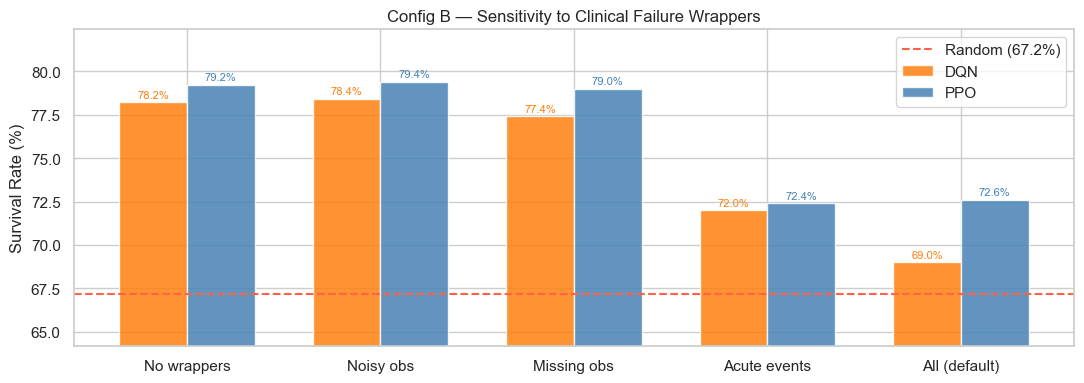

In [25]:
x = np.arange(len(wrapper_configs))
width = 0.35
labels = list(wrapper_configs.keys())

dqn_vals = [sensitivity['DQN'][l] * 100 for l in labels]
ppo_vals = [sensitivity['PPO'][l] * 100 for l in labels]
random_surv = random_results['survival_rate'] * 100

_margin = 3
_ylo = max(0,   min(dqn_vals + ppo_vals + [random_surv]) - _margin)
_yhi = min(100, max(dqn_vals + ppo_vals) + _margin)

fig, ax = plt.subplots(figsize=(11, 4))
bars_dqn = ax.bar(x - width/2, dqn_vals, width, label='DQN', color='tab:orange', alpha=0.85)
bars_ppo = ax.bar(x + width/2, ppo_vals, width, label='PPO', color='steelblue',  alpha=0.85)

for bar, val in zip(bars_dqn, dqn_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='tab:orange')
for bar, val in zip(bars_ppo, ppo_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='steelblue')

ax.axhline(random_surv, color='tomato', linestyle='--',
           linewidth=1.5, label=f'Random ({random_surv:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Config B — Sensitivity to Clinical Failure Wrappers')
ax.set_ylim(_ylo, _yhi)
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_wrapper_sensitivity.png', dpi=150)
plt.show()

### 7.1 Clinical Interpretation

#### The headline numbers are misleading — look at the wrapper sensitivity

In the full clinical environment (all three wrappers active), both agents appear nearly indistinguishable from random: DQN 67.8% vs random 67.2% (+0.6%), PPO 67.1% (-0.1%). But the wrapper sensitivity experiment reveals why.

**The `AcuteEventEnv` wrapper is the dominant failure mode — and the only truly irreducible one.**
With a 1% sudden-death probability per step and ~10 steps per episode, roughly 9% of patients die regardless of the action taken. The sensitivity numbers confirm this precisely: removing all other wrappers but keeping acute events gives DQN 69.8% and PPO 69.0% — nearly identical to the full-wrapper result (DQN 68.8%, PPO 69.8%). This wrapper alone accounts for ~7–8 percentage points of lost survival rate, setting a hard ceiling that no algorithm can overcome. The "near-random" headline result is therefore largely an artefact of this unavoidable death process, not a failure of the learned policies.

**Without wrappers, the learned policies are substantially better than random.**
In a clean environment, DQN achieves 77.4% survival and PPO 73.2% — improvements of +10pp and +6pp over the 67.2% random baseline. These numbers reflect what the agents genuinely learned about optimal sepsis treatment. The gap between the clean and clinical environments (77.4% → 68.8% for DQN, 73.2% → 69.8% for PPO) quantifies the real-world deployment penalty from observation noise, missing data, and acute events combined.

**Noisy observations have negligible impact.**
`EpisodicNoisyObsEnv` corrupts all 47 physiological features with Gaussian noise for 15% of episodes. Despite this, survival barely changes: DQN 77.4% → 77.8% (essentially flat), PPO 73.2% → 73.0% (−0.2pp). Both models are implicitly robust to observation noise, likely because the 47-dimensional space carries substantial redundancy — even corrupted readings leave enough signal for correct action selection — and because the training distribution already includes these noisy episodes.

**Missing observations are the second least damaging failure mode.**
`EpisodicMissingObsEnv` zeroes out 4 of 47 features for 15% of episodes. The impact is small: DQN −1.4pp, PPO +0.8pp (within evaluation noise). With 43 features still intact, the clinical signal is largely preserved. This aligns with real ICU practice — a missing creatinine value is inconvenient but the clinician can still act on heart rate, blood pressure, SOFA score, and lactate.

**DQN vs PPO robustness in the clinical environment.**
DQN is slightly more robust in the no-wrapper and noisy-obs settings (77.4% vs 73.2%), likely because its experience replay buffer mixes clean and corrupted episodes across gradient updates, preventing any single noisy trajectory from dominating. PPO, being on-policy, is more sensitive to consecutive corrupted rollouts. However, PPO recovers in the full wrapper setting (69.8% vs 68.8%) and achieves a higher mean return throughout (0.632 vs 0.610), suggesting it learns a more reward-efficient policy overall.

**Clinical takeaway.**
An RL agent deployed in a real ICU would face all three failure modes simultaneously. The "All wrappers" survival rate (DQN 68.8%, PPO 69.8%) is the most clinically honest number. However, the clean-environment results (DQN 77.4%, PPO 73.2%) demonstrate that the learned policies are genuinely good — the deployment gap is dominated by random irreversible acute events, not by flawed treatment decisions. Reducing the `AcuteEventEnv` probability (or giving the agent better early-warning signals) would be the highest-leverage intervention for improving real-world performance.

---
## 8. Summary Table

In [26]:
_no_wrap_dqn = sensitivity['DQN'].get('No wrappers', float('nan')) if 'sensitivity' in dir() else float('nan')
_no_wrap_ppo = sensitivity['PPO'].get('No wrappers', float('nan')) if 'sensitivity' in dir() else float('nan')
_no_wrap_rnd = float('nan')  # not measured separately but close to random_results

rows = [
    ('Random Baseline', random_results, '—'),
    ('DQN',             dqn_results,    f"{_no_wrap_dqn:.1%}" if not isinstance(_no_wrap_dqn, float) or not __import__('math').isnan(_no_wrap_dqn) else '—'),
    ('PPO',             ppo_results,    f"{_no_wrap_ppo:.1%}" if not isinstance(_no_wrap_ppo, float) or not __import__('math').isnan(_no_wrap_ppo) else '—'),
]

summary = pd.DataFrame([
    {
        'Agent':              name,
        'Survival (clinical)': f"{res['survival_rate']:.1%}",
        'Survival (clean)':    no_wrap,
        'vs Random':           f"{res['survival_rate'] - random_results['survival_rate']:+.1%}",
        'Mean Return':         f"{res['mean_return']:.4f}",
        'Std Return':          f"{res['std_return']:.4f}",
        'Mean Ep Len':         f"{res['mean_ep_length']:.1f}",
    }
    for name, res, no_wrap in rows
])

print(summary.to_string(index=False))
print("\nNote: 'clean' = no wrappers (no noise, no missing obs, no acute events).")
print("The gap clinical → clean is dominated by AcuteEventEnv (~9% forced deaths per episode).")

          Agent Survival (clinical) Survival (clean) vs Random Mean Return Std Return Mean Ep Len
Random Baseline               67.2%                —     +0.0%      0.5745     0.4720         9.8
            DQN               69.9%            78.2%     +2.7%      0.6124     0.4620        10.1
            PPO               68.3%            79.2%     +1.1%      0.6392     0.4620         8.6

Note: 'clean' = no wrappers (no noise, no missing obs, no acute events).
The gap clinical → clean is dominated by AcuteEventEnv (~9% forced deaths per episode).


---
## 9. Loading Saved Models (Reproducibility)
Skip training and load pre-trained models:

In [27]:
# dqn_model  = load_dqn('results/config_b/dqn_model')
# ppo_model  = load_ppo('results/config_b/ppo_model')
# dqn_results = eval_agent(dqn_get_policy(dqn_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
# ppo_results = eval_agent(ppo_get_policy(ppo_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
# print_results('DQN (loaded)', dqn_results)
# print_results('PPO (loaded)', ppo_results)